In [1]:
from urllib import request
import os
import tarfile
import glob

In [2]:
filename, _ = request.urlretrieve('https://www.robots.ox.ac.uk/~vgg/data/flowers/17/17flowers.tgz', 'flowers.tgz')

In [3]:
print(os.stat(filename))

os.stat_result(st_mode=33206, st_ino=13510798882384939, st_dev=18023550114672613681, st_nlink=1, st_uid=0, st_gid=0, st_size=60270631, st_atime=1765731475, st_mtime=1765731475, st_ctime=1765677715)


In [4]:
tar = tarfile.open(filename)
tar.extractall(path='train_data')
tar.close()

C:\Users\amir\AppData\Local\Temp\ipykernel_13268\1675404005.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='train_data')


In [5]:
image_paths = sorted(glob.glob('train_data/jpg/*.jpg'))

In [6]:
image_paths

['train_data/jpg\\image_0001.jpg',
 'train_data/jpg\\image_0002.jpg',
 'train_data/jpg\\image_0003.jpg',
 'train_data/jpg\\image_0004.jpg',
 'train_data/jpg\\image_0005.jpg',
 'train_data/jpg\\image_0006.jpg',
 'train_data/jpg\\image_0007.jpg',
 'train_data/jpg\\image_0008.jpg',
 'train_data/jpg\\image_0009.jpg',
 'train_data/jpg\\image_0010.jpg',
 'train_data/jpg\\image_0011.jpg',
 'train_data/jpg\\image_0012.jpg',
 'train_data/jpg\\image_0013.jpg',
 'train_data/jpg\\image_0014.jpg',
 'train_data/jpg\\image_0015.jpg',
 'train_data/jpg\\image_0016.jpg',
 'train_data/jpg\\image_0017.jpg',
 'train_data/jpg\\image_0018.jpg',
 'train_data/jpg\\image_0019.jpg',
 'train_data/jpg\\image_0020.jpg',
 'train_data/jpg\\image_0021.jpg',
 'train_data/jpg\\image_0022.jpg',
 'train_data/jpg\\image_0023.jpg',
 'train_data/jpg\\image_0024.jpg',
 'train_data/jpg\\image_0025.jpg',
 'train_data/jpg\\image_0026.jpg',
 'train_data/jpg\\image_0027.jpg',
 'train_data/jpg\\image_0028.jpg',
 'train_data/jpg\\im

In [7]:
import os, glob, shutil

class_names = [
    'Buttercup','ColtsFoot','Daffodi','Daisy','Dandelion','Fritillary',
    'Iris','Pansy','Sunflower','Windflower','Snowdrop','LilyValley',
    'Bluebell','Crocus','Tigerlily','Tulip','Cowslip','Amir'
]

image_paths = sorted(glob.glob(os.path.join('train_data','jpg','*.jpg')))

i, j = 0, 80

for cls in class_names:
    class_dir = os.path.join('train_data', cls)
    os.makedirs(class_dir, exist_ok=True)

    for idx, src in enumerate(image_paths[i:j], 1):
        dst = os.path.join(class_dir, f'{idx}.jpg')
        if os.path.exists(dst):
            os.remove(dst)         
        shutil.move(src, dst)     

    i += 80
    j += 80




In [8]:
print(image_paths[0])


train_data\jpg\image_0001.jpg


In [14]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [15]:
cv2

<module 'cv2' from 'c:\\Users\\amir\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\cv2\\__init__.py'>

In [16]:
img = cv2.imread('train_data/Bluebell/1.jpg')

In [17]:
image_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [18]:
image = cv2.resize(img, (500, 500))
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
hist = cv2.calcHist([image], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
cv2.normalize(hist, hist)
image_histogram = hist.flatten()

In [20]:
np.shape(image_histogram)

(512,)

In [21]:
image_hsv

array([[[ 41, 125,  92],
        [ 41, 103, 109],
        [ 40, 100, 110],
        ...,
        [  0,  46,  89],
        [  0,  46,  88],
        [  0,  46,  88]],

       [[ 41, 127,  90],
        [ 41, 108, 104],
        [ 40, 104, 105],
        ...,
        [  0,  44,  93],
        [  0,  44,  92],
        [  0,  44,  92]],

       [[ 42, 129,  91],
        [ 42, 118,  99],
        [ 41, 111, 103],
        ...,
        [  0,  42,  98],
        [  0,  42,  98],
        [  0,  42,  98]],

       ...,

       [[ 47, 255,  14],
        [ 47, 255,  14],
        [ 43, 255,  14],
        ...,
        [ 15,  84,  94],
        [ 15,  78, 104],
        [ 15,  73, 112]],

       [[ 47, 255,  14],
        [ 47, 255,  14],
        [ 43, 255,  14],
        ...,
        [ 15,  88,  90],
        [ 15,  83,  98],
        [ 15,  76, 107]],

       [[ 47, 255,  14],
        [ 47, 255,  14],
        [ 43, 255,  14],
        ...,
        [ 15,  91,  87],
        [ 15,  86,  95],
        [ 15,  79, 103]]

In [22]:
np.shape(img)

(500, 611, 3)

In [23]:
print(img[0])

[[ 45  90  73]
 [ 62 107  90]
 [ 71 114  99]
 ...
 [ 72  72  88]
 [ 72  72  88]
 [ 72  72  88]]


In [25]:
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

In [26]:
hist

array([[2.4838e+04],
       [6.9120e+03],
       [7.2310e+03],
       [6.9980e+03],
       [6.9070e+03],
       [6.8040e+03],
       [6.3510e+03],
       [6.4240e+03],
       [6.0190e+03],
       [5.6770e+03],
       [5.4690e+03],
       [5.3440e+03],
       [5.0670e+03],
       [4.8910e+03],
       [4.6590e+03],
       [4.4720e+03],
       [4.1900e+03],
       [4.0190e+03],
       [3.9750e+03],
       [3.7980e+03],
       [3.6210e+03],
       [3.5090e+03],
       [3.4110e+03],
       [3.4040e+03],
       [3.2050e+03],
       [3.1180e+03],
       [3.0220e+03],
       [3.0360e+03],
       [2.9270e+03],
       [2.8630e+03],
       [2.7270e+03],
       [2.6650e+03],
       [2.5790e+03],
       [2.4550e+03],
       [2.3500e+03],
       [2.3270e+03],
       [2.2280e+03],
       [2.3490e+03],
       [2.3960e+03],
       [2.4250e+03],
       [2.3730e+03],
       [2.3890e+03],
       [2.4850e+03],
       [2.3940e+03],
       [2.2770e+03],
       [2.3360e+03],
       [2.2330e+03],
       [2.108

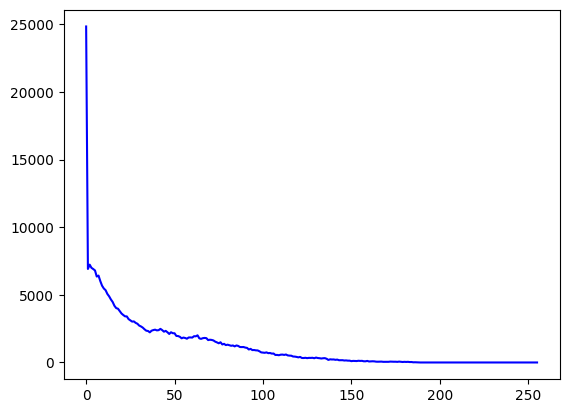

In [27]:
plt.plot(hist, color='blue')

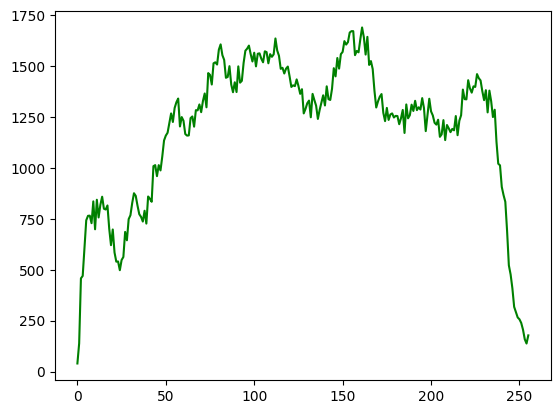

In [28]:
hist = cv2.calcHist([img], [1], None, [256], [0, 256])
plt.plot(hist, color='green')

In [30]:
grayImg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hue_features = cv2.HuMoments(cv2.moments(grayImg)).flatten()

In [31]:
hue_features

array([ 1.13115987e-03,  1.52695277e-08,  3.54396481e-11,  2.20732752e-11,
       -1.09707513e-22,  9.91670412e-16, -6.07543273e-22])